In [1]:
%%capture
pip install -U peft transformers diffusers openai
pip install git+https://github.com/openai/CLIP.git
# !git clone https://github.com/christophschuhmann/improved-aesthetic-predictor.git

# import sys
# sys.path.append("improved-aesthetic-predictor")

SyntaxError: invalid syntax (88155208.py, line 1)

In [2]:
from diffusers import DiffusionPipeline
# from aesthetic_predictor import AestheticPredictor
from transformers import Blip2Processor, Blip2Model
from openai import OpenAI
import torch
import clip
from PIL import Image
import os
import torch.nn.functional as F

KeyboardInterrupt: 

In [ ]:
my_token = "" #add your token here

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# Load Stable Diffusion XL Base1.0
pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
).to(device)

# Optional CPU offloading to save some GPU Memory
# pipe.enable_model_cpu_offload()

# Loading Trained LoRA Weights
pipe.load_lora_weights("AdamLucek/sdxl-base-1.0-oldbookillustrations-lora")

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:

endpoint = "https://models.github.ai/inference"
model = "openai/gpt-4.1"

client = OpenAI(
    base_url=endpoint,
    api_key=my_token,
)

SYSTEM = (
    "You are a Prompt Enhancer for text-to-image models. "
    "You refine historical prompts for diffusion models with high clarity, detail, and historical accuracy."
)

def enhance_prompt(user_prompt):
    TEMPLATE = f"""
Rewrite this prompt for generating a historical image, if user_prompt is Vietnamese, translate it into English:

<USER_PROMPT>
{user_prompt}

Requirements:
- less than 77 tokens
- Historically consistent details
- Add atmosphere, environment, clothing, lighting
- No modern elements unless requested
- Detailed in description
- Output ONLY
"""

    response = client.chat.completions.create(
        model= model,
        messages=[
            {"role": "system", "content": SYSTEM},
            {"role": "user", "content": TEMPLATE},
        ],
        temperature=0.2,
    )

    return response.choices[0].message.content


In [ ]:
user_prompt = "Bác Hồ ra đi tìm đường cứu nước tại bến cảng nhà rồng"

enhanced_prompt = enhance_prompt(user_prompt)
enhanced_prompt

'Ho Chi Minh, dressed in early 20th-century attire, stands solemnly at Nha Rong Wharf in Saigon, preparing to depart on his journey to seek national salvation. The atmosphere is misty at dawn, with colonial architecture in the background, dock workers nearby, and soft golden light illuminating the scene.'

In [ ]:
number_of_images = 3


images = [pipe(
    prompt = enhanced_prompt,
    num_inference_steps=40,
    height=576,
    width=1024,
    guidance_scale=7.0,
).images[0] for _ in range(number_of_images)]

  0%|          | 0/40 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
clip_model, preprocess = clip.load("ViT-B/32", device=device)

text_token = clip.tokenize([enhanced_prompt]).to(device)

with torch.no_grad():
    text_features = clip_model.encode_text(text_token)

clip_scores = []

for img in images:
    image_tensor = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = clip_model.encode_image(image_tensor)
    similarity = (image_features @ text_features.T).item()
    clip_scores.append(similarity)

clip_scores

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 158MiB/s]


[20.890596389770508, 24.63441276550293, 20.082061767578125]

In [ ]:
# predictor = AestheticPredictor("clip-ViT-B-32")
# aesthetic_scores = predictor(images)
# aesthetic_scores

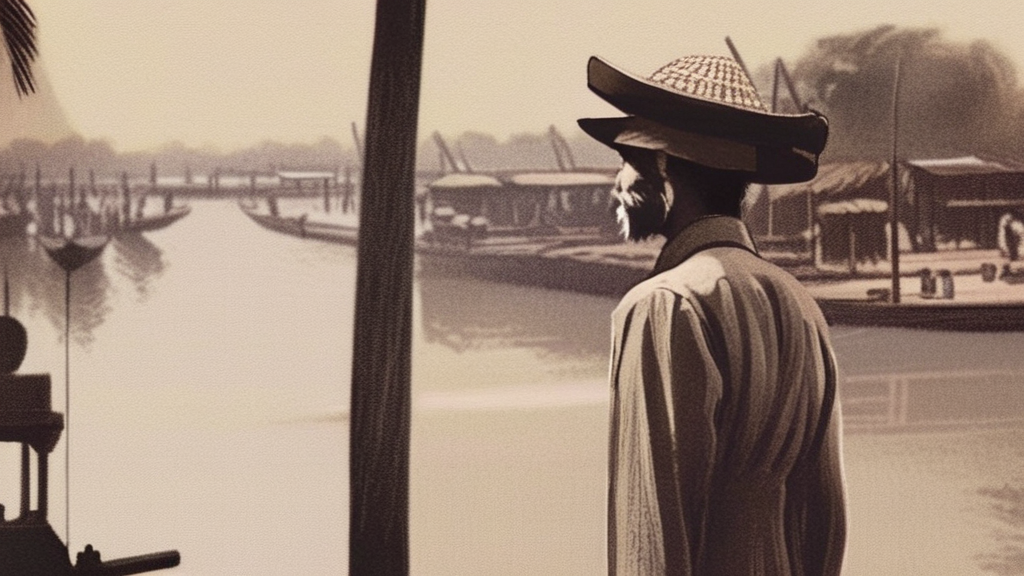

In [ ]:
best_image_index = torch.argmax(torch.tensor(clip_scores))
best_image = images[best_image_index]
best_image